# Data Visualization and Dashboarding

## Objective

The objective of this task is to create professional visualizations and dashboards to understand customer behavior, churn patterns, customer value, and service usage using the IBM Telco Customer Churn dataset.

The analysis uses Matplotlib, Seaborn, and Plotly for visualization and prepares the dataset for dashboard development in Power BI.

## Import Libraries

In [10]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

## Load Dataset

In [2]:
df = pd.read_csv('../data/processed/telco_cleaned.csv')
df

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,...,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,45,5306,NaN
7039,6840-RESVB,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,No,59,2140,NaN
7040,2234-XADUH,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,71,5560,NaN
7041,4801-JZAZL,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,59,2793,NaN


In [3]:
df.columns

Index(['CustomerID', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
       'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

---------------------
## Matplotlib Visualizations

## Objective

Create basic visualizations to understand numerical and categorical patterns within the customer dataset.


### 1. Monthly Charges

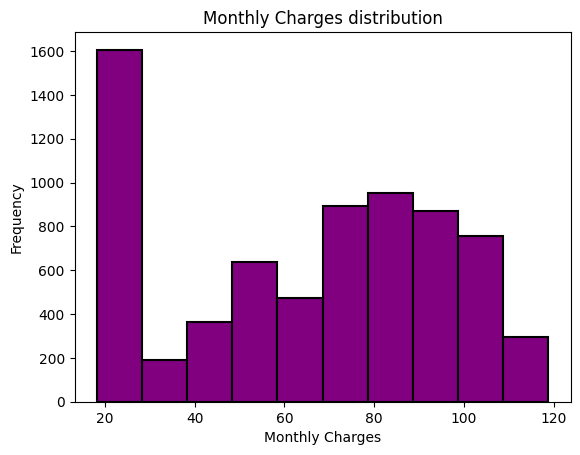

In [66]:
plt.hist(df['Monthly Charges'],color='purple',edgecolor='black',linewidth=1.5)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Monthly Charges distribution')
plt.savefig("../visualizations/monthly_charges_histogram.png")

### Observation

The histogram illustrates the distribution of monthly customer charges. Most customers fall within the moderate billing range.

-------------------------------

### 2. Contract Type Distribution

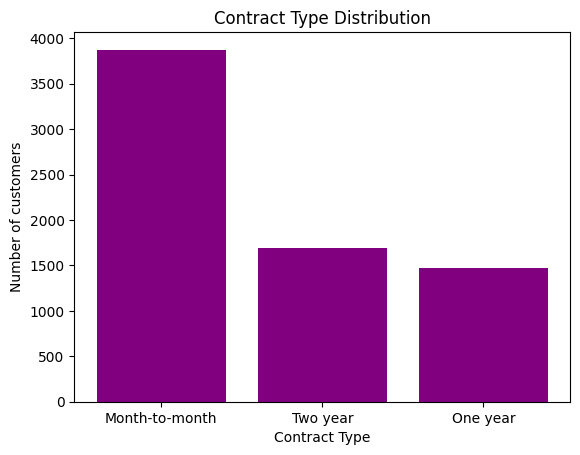

In [67]:
count = df['Contract'].value_counts()
plt.bar(count.index,count,color='purple')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.title('Contract Type Distribution')
plt.savefig("../visualizations/contract_distribution.png")

### Observation

Month-to-month contracts represent the largest customer segment, indicating a preference for flexible subscription plans.

-----------------------

### 3. Tenure Months vs Total Charges

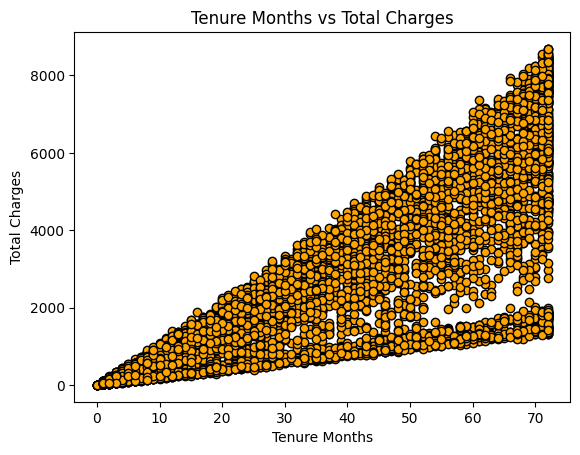

In [68]:
plt.scatter(df['Tenure Months'],df['Total Charges'],color='orange',edgecolor='black')
plt.xlabel('Tenure Months')
plt.ylabel('Total Charges')
plt.title('Tenure Months vs Total Charges')
plt.savefig("../visualizations/tenure_vs_total_charges.png")

### Observation

A positive relationship exists between tenure and total charges. Customers who stay longer with the company accumulate higher total charges.

-------------------------------------
### 4. Average Customer Lifetime Value by Tenure

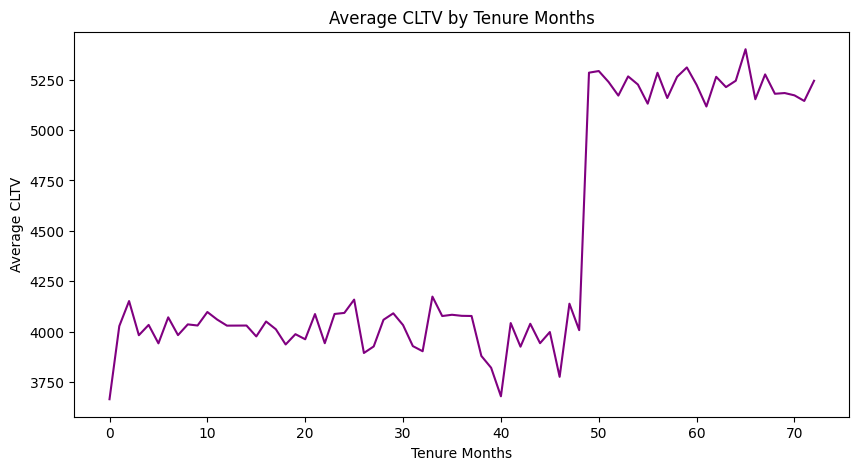

In [69]:
avg_cltv = df.groupby("Tenure Months")["CLTV"].mean().reset_index()
plt.figure(figsize=(10,5))

plt.plot(avg_cltv["Tenure Months"],avg_cltv["CLTV"],color='purple')
plt.title("Average CLTV by Tenure Months")
plt.xlabel("Tenure Months")
plt.ylabel("Average CLTV")
plt.savefig("../visualizations/cltv_by_tenure.png")
plt.show()

### Observation

The line chart shows a generally increasing trend between customer tenure and average customer lifetime value (CLTV). Customers who remain with the company for longer periods tend to generate greater lifetime value, highlighting the importance of customer retention strategies.

---------------------

# Seaborn Visualizations

## Objective

Use advanced statistical visualizations to analyze relationships between variables and customer churn behavior.

### Correlation Matrix

In [38]:
mat = df[["Tenure Months","Monthly Charges","Total Charges","CLTV","Churn Score"]]
mat.corr()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Score
Tenure Months,1.000000,0.247900,0.826178,0.396406,-0.224987
Monthly Charges,0.247900,1.000000,0.651174,0.098693,0.133754
Total Charges,0.826178,0.651174,1.000000,0.342091,-0.123410
CLTV,0.396406,0.098693,0.342091,1.000000,-0.079782
Churn Score,-0.224987,0.133754,-0.123410,-0.079782,1.000000


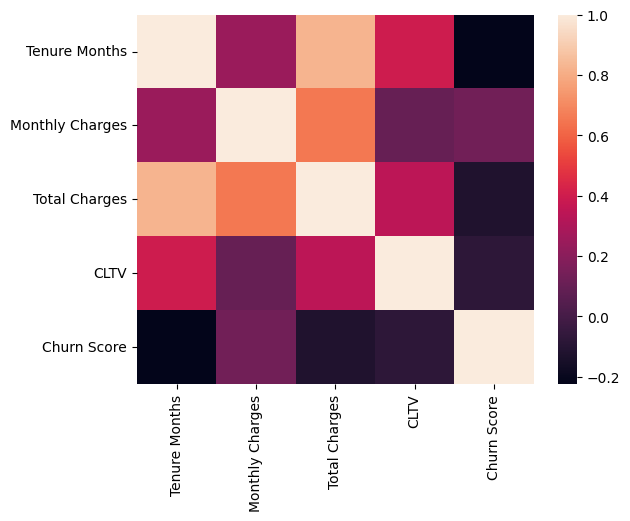

In [71]:
sns.heatmap(mat.corr())
plt.savefig("../visualizations/correlation_heatmap.png",bbox_inches="tight")

### Observation

Tenure Months and Total Charges exhibit the strongest positive correlation, suggesting that long-term customers generate higher revenue.

----------------------------------
### Monthly Charges by Churn Status

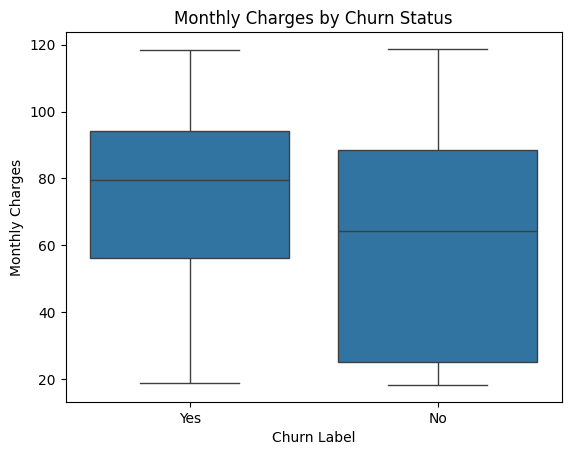

In [72]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title("Monthly Charges by Churn Status")
plt.savefig("../visualizations/monthly_charges_boxplot.png",bbox_inches="tight")
plt.show()

### Observation

Customers who churn tend to have different monthly charge distributions compared to retained customers, indicating pricing may influence retention.

---------------------
### Pairplot Analysis

#### Objective

To analyze pairwise relationships among important numerical variables and identify trends, correlations, and customer behavior patterns.

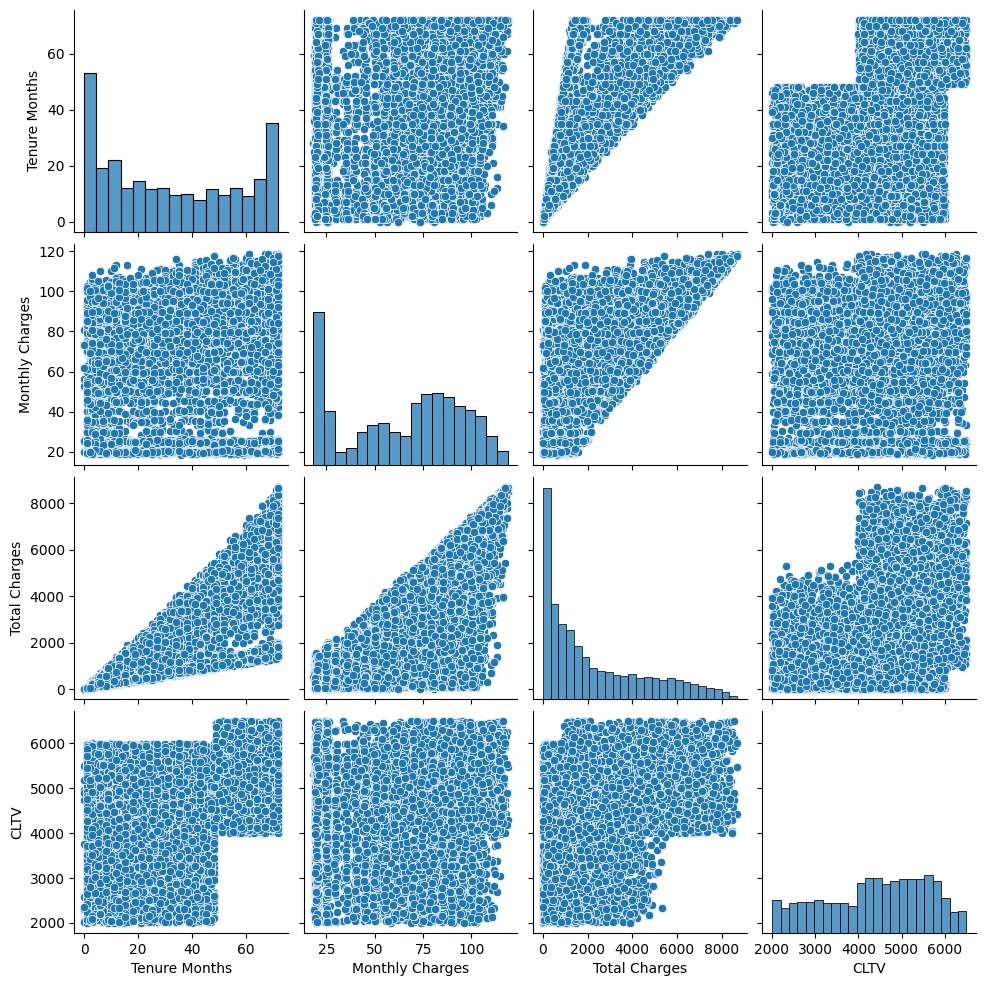

In [73]:
pair = df[["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]]
sns.pairplot(pair)
plt.savefig("../visualizations/pairplot.png",bbox_inches="tight")

### Observation

The pairplot provides a comprehensive view of relationships among Tenure Months, Monthly Charges, Total Charges, and Customer Lifetime Value (CLTV).

Key observations include:

- A strong positive relationship exists between Tenure Months and Total Charges, indicating that customers who stay longer contribute higher cumulative revenue.

- CLTV generally increases with customer tenure, suggesting that long-term customers are more valuable to the business.

- Monthly Charges show a moderate relationship with Total Charges, as customers with higher monthly bills tend to accumulate greater overall spending.

- The diagonal distributions reveal variation in customer tenure, spending patterns, and lifetime value, highlighting the presence of different customer segments within the dataset.

### Insight

The pairplot confirms that customer retention plays a critical role in revenue generation and customer lifetime value. Customers with longer tenures consistently contribute higher total charges and greater lifetime value, emphasizing the importance of customer retention strategies.

--------------------------
# Interactive Visualizations Using Plotly

## Objective

To create interactive visualizations that enable dynamic exploration of customer behavior, contract preferences, and churn patterns.

### Contract Type Distribution (Interactive)

In [74]:
contractcount = df['Contract'].value_counts().reset_index()
contractcount.columns=['Contract','Count']
fig = px.bar(contractcount,x = 'Contract', y = 'Count',title="Customer Distribution by Contract Type")
fig.write_html("../visualizations/contract_distribution_interactive.html")
fig.show()


### Observation

The interactive bar chart provides a clear view of customer distribution across contract types. Month-to-month contracts account for the largest share of customers, while one-year and two-year contracts represent smaller customer segments.

### Insight

The dominance of month-to-month contracts suggests that customers prefer flexible subscription options. However, this segment may require additional retention efforts due to higher churn risk.

----------------------------

### Customer Churn Distribution (Interactive)

In [75]:
churncount = df['Churn Label'].value_counts().reset_index()
churncount.columns = ['Churn Status','Count']
fig = px.pie(churncount, names="Churn Status", values="Count", title="Customer Churn Distribution")
fig.write_html("../visualizations/churn_distribution_interactive.html")
fig.show()

### Observation

The interactive pie chart illustrates the proportion of customers who remained with the company compared to those who churned. The majority of customers were retained, while a smaller percentage discontinued services.

### Insight

Although customer retention remains relatively strong, the churned customer segment represents a significant business concern. Understanding the factors driving churn can support more effective retention strategies.

-------------------------------------

## Exported Visualizations

All visualizations were exported as PNG and HTML files and stored for reporting, presentation, and dashboard development purposes.

---------

# Key Insights

1. Month-to-month contracts represent the largest customer segment.

2. Customer Lifetime Value generally increases with customer tenure.

3. Tenure Months and Total Charges exhibit a strong positive relationship.

4. Monthly Charges vary between churned and non-churned customers.

5. A significant proportion of churn occurs within customers using flexible contract plans.

-------------------

# Conclusion

Visualization techniques using Matplotlib, Seaborn, and Plotly were applied to explore customer behavior, revenue patterns, and churn trends. The analysis revealed strong relationships between tenure, total charges, and customer lifetime value. Interactive visualizations further improved the ability to explore customer segments and identify business opportunities for improving retention.